# Notebook 4 — Fusion et préparation du tableau d'entraînement
## Croisement pluviomètre × pluviographe sur la période commune

---

## Objectif

Ce notebook crée le **tableau d'entraînement** nécessaire au Notebook 5 (modélisation).  
Il croise les deux sources de données pour obtenir, pour chaque jour de la période commune :
- La **pluie journalière** (mm) —Issue du pluviomètre
- L'**intensité maximale** (mm/h) — Issue du pluviographe

### Pourquoi cette fusion est-elle nécessaire ?

Le pluviographe (intensités à pas fins) ne couvre que **2004–présent**, alors que le  
pluviomètre (pluies journalières) couvre **1980–présent**. Pour **reconstituer** les  
intensités manquantes de 1980 à 2003, il faut apprendre la relation :

$$\text{intensité\_max} = f(\text{pluie\_journalière})$$

sur la période où les deux sources se chevauchent (2004–2014), puis appliquer  
cette relation aux années 1980–2003.

### Livrable

| Fichier | Contenu |
|---------|--------|
| `data/tableau_entrainement.csv` | `[date, pluie_mm, intensite_max_mm_h, mois, saison]` |

---


## 0. Configuration et imports

In [1]:
import os
import warnings

warnings.filterwarnings('ignore')

NB = 'n4'
FIG_DIR = f'figures/{NB}'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs('data', exist_ok=True)

print(f'Répertoire figures : {FIG_DIR}')

Répertoire figures : figures/n4


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats as sp_stats

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linewidth':   0.6,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'figure.dpi':       100,
})

print('Imports chargés')

Imports chargés


---
## Section 1 — Chargement des CSV nettoyés

On charge les deux fichiers produits par le Notebook 3 :
- `pluviometre_clean.csv` : pluies journalières (1980–2014)
- `pluviographe_clean.csv` : événements pluvieux avec intensités (2004–2014)

In [3]:
df_pm = pd.read_csv('data/pluviometre_clean.csv', parse_dates=['date'])
df_pg = pd.read_csv('data/pluviographe_clean.csv', parse_dates=['date'])

print(f'Pluviomètre : {len(df_pm)} lignes | {df_pm.date.min().date()} → {df_pm.date.max().date()}')
print(f'Pluviographe: {len(df_pg)} lignes | {df_pg.date.min().date()} → {df_pg.date.max().date()}')
print(f'\nDurées pluviographe (min): {sorted(df_pg.duree_min.unique())}')

Pluviomètre : 8182 lignes | 1980-01-06 → 2014-12-31
Pluviographe: 1115 lignes | 2004-06-01 → 2014-10-31

Durées pluviographe (min): [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 48.0, 54.0, 60.0, 66.0, 72.0, 78.0, 84.0, 90.0, 96.0, 102.0, 108.0, 114.0, 120.0, 124.0, 126.0, 128.0, 132.0, 134.0, 138.0, 144.0, 148.0, 150.0, 156.0, 162.0, 168.0, 174.0, 178.0, 180.0, 184.0, 186.0, 192.0, 198.0, 204.0, 210.0, 216.0, 222.0, 224.0, 226.0, 228.0, 234.0, 240.0, 246.0, 248.0, 252.0, 258.0, 264.0, 270.0, 282.0, 288.0, 294.0, 300.0, 306.0, 312.0, 318.0, 324.0, 330.0, 336.0, 348.0, 354.0, 360.0, 366.0, 378.0, 384.0, 386.0, 390.0, 408.0, 414.0, 426.0, 438.0, 478.0, 480.0, 512.0, 518.0, 624.0]


---
## Section 2 — Calcul de l'intensité max journalière

Le pluviographe enregistre **plusieurs événements par jour** (matin + soir) et  
**plusieurs durées** par événement. Pour la modélisation, on besoin d'**une seule valeur**  
représentative par jour : l'**intensité maximale** toutes durées confondues.

### Logique

Pour chaque date, on prend le maximum de `intensite_mm_h` parmi tous les événements  
et toutes les durées de cette date. C'est cette valeur qui sera modélisée en fonction  
de la pluie journalière correspondante.

In [4]:
# Agrégation : intensité max journalière (toutes durées confondues)
imax_jour = df_pg.groupby('date')['intensite_mm_h'].max().reset_index()
imax_jour.columns = ['date', 'intensite_max_mm_h']

print(f'{len(imax_jour)} jours avec données pluviographe')
print(f'Intensité max minimale : {imax_jour.intensite_max_mm_h.min():.1f} mm/h')
print(f'Intensité max maximale : {imax_jour.intensite_max_mm_h.max():.1f} mm/h')
print(f'Intensité max médiane  : {imax_jour.intensite_max_mm_h.median():.1f} mm/h')
imax_jour.head()

909 jours avec données pluviographe
Intensité max minimale : 0.1 mm/h
Intensité max maximale : 570.0 mm/h
Intensité max médiane  : 6.3 mm/h


,date,intensite_max_mm_h
0,2004-06-01,6.281250
1,2004-06-03,3.333333
2,2004-06-04,17.400000
3,2004-06-06,19.250000
4,2004-06-07,22.666667


---
## Section 3 — Fusion sur la période commune

### Stratégie de jointure

On effectue une **jointure interne** (`inner join`) sur la colonne `date`.  
Cela ne conserve que les jours où les **deux sources** ont des données.

### Fallback si peu de données communes

Si la période commune contient **moins de 10 jours**, on utilise toute la période  
disponible du pluviographe (fallback documenté).

### Variables temporelles ajoutées

- `mois` : numéro du mois (1–12)
- `saison` : classification en 3 saisonns :
  - **seche** : novembre à mars
  - **transition** : avril, mai, octobre
  - **pluies** : juin à septembre

In [5]:
# Période commune
debut_commun = max(df_pm.date.min(), df_pg.date.min())
fin_commun   = min(df_pm.date.max(), df_pg.date.max())
print(f'Période commune : {debut_commun.date()} → {fin_commun.date()}')

# Filtrer le pluviomètre sur la période commune
df_pm_com = df_pm[(df_pm.date >= debut_commun) & (df_pm.date <= fin_commun)].copy()

# Jointure inner join sur la date
df_train = pd.merge(df_pm_com[['date', 'pluie_mm']], imax_jour, on='date', how='inner')
df_train = df_train.dropna(subset=['pluie_mm', 'intensite_max_mm_h'])

# Variables temporelles
df_train['mois'] = df_train['date'].dt.month
df_train['saison'] = df_train['mois'].map({
    1: 'seche', 2: 'seche', 3: 'seche',
    4: 'transition', 5: 'transition',
    6: 'pluies', 7: 'pluies', 8: 'pluies', 9: 'pluies',
    10: 'pluies', 11: 'transition', 12: 'seche'
})

print(f'\nTableau d\'entraînement : {len(df_train)} lignes')
print(f'Colonnes : {list(df_train.columns)}')
df_train.head()

Période commune : 2004-06-01 → 2014-10-31

Tableau d'entraînement : 617 lignes
Colonnes : ['date', 'pluie_mm', 'intensite_max_mm_h', 'mois', 'saison']


,date,pluie_mm,intensite_max_mm_h,mois,saison
0,2004-06-03,0.0,3.333333,6,pluies
1,2004-06-04,4.0,17.400000,6,pluies
2,2004-06-06,0.0,19.250000,6,pluies
3,2004-06-08,6.2,7.434783,6,pluies
4,2004-06-09,2.7,2.000000,6,pluies


In [6]:
# Vérification : fallback si peu de données communes
if len(df_train) < 10:
    print('AVERTISSEMENT: Peu de données communes (<10 jours).')
    print('Utilisation de toute la période du pluviographe.')
    df_train = pd.merge(df_pm[['date', 'pluie_mm']], imax_jour, on='date', how='inner')
    df_train = df_train.dropna(subset=['pluie_mm', 'intensite_max_mm_h'])
    df_train['mois'] = df_train['date'].dt.month
    df_train['saison'] = df_train['mois'].map({
        1: 'seche', 2: 'seche', 3: 'seche', 4: 'transition',
        5: 'transition', 6: 'pluies', 7: 'pluies', 8: 'pluies',
        9: 'pluies', 10: 'pluies', 11: 'transition', 12: 'seche'
    })
    print(f'Tableau final : {len(df_train)} lignes')
else:
    print(f'OK : {len(df_train)} jours communs disponibles.')

# Statistiques de base
print(f'\n=== Statistiques du tableau d\'entraînement ===')
print(f'Pluie journalière   : moy={df_train.pluie_mm.mean():.1f} mm, '
      f'max={df_train.pluie_mm.max():.1f} mm')
print(f'Intensité max       : moy={df_train.intensite_max_mm_h.mean():.1f} mm/h, '
      f'max={df_train.intensite_max_mm_h.max():.1f} mm/h')
print(f'Répartition saisons :')
print(df_train['saison'].value_counts().to_string())

OK : 617 jours communs disponibles.

=== Statistiques du tableau d'entraînement ===
Pluie journalière   : moy=12.2 mm, max=351.4 mm
Intensité max       : moy=12.5 mm/h, max=497.0 mm/h
Répartition saisons :
saison
pluies    617


---
## Section 4 — Corrélation pluie journalière vs intensité max

Avant de modéliser, on vérifie visuellement et quantitativement la relation entre  
la pluie journalière (variable explicative) et l'intensité maximale (variable cible).

On calcule :
- Le **coefficient de Pearson** sur l'échelle linéaire
- Le **coefficient de Pearson sur log-log** (la relation est souvent de type puissance)

In [7]:
df_plot = df_train[df_train.pluie_mm > 0].copy()

# Corrélation linéaire
r_lin, p_lin = sp_stats.pearsonr(df_plot.pluie_mm, df_plot.intensite_max_mm_h)

# Corrélation log-log
mask_pos = (df_plot.pluie_mm > 0) & (df_plot.intensite_max_mm_h > 0)
r_log, p_log = sp_stats.pearsonr(
    np.log(df_plot.loc[mask_pos, 'pluie_mm']),
    np.log(df_plot.loc[mask_pos, 'intensite_max_mm_h'])
)

print(f'Corrélation linéaire : r = {r_lin:.3f} (p = {p_lin:.2e})')
print(f'Corrélation log-log  : r = {r_log:.3f} (p = {p_log:.2e})')
print(f'\n→ La corrélation log-log est plus forte, ce qui justifie la transformation log.')

Corrélation linéaire : r = 0.074 (p = 9.42e-02)
Corrélation log-log  : r = 0.107 (p = 1.52e-02)

→ La corrélation log-log est plus forte, ce qui justifie la transformation log.


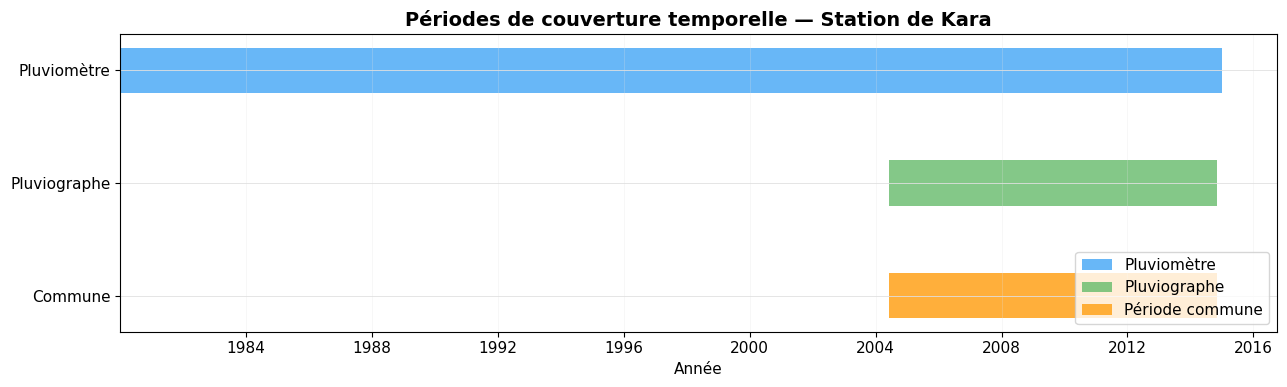

fig1 sauvegardée


In [8]:
# ==============================================================================
# FIGURE 1 — Périodes de couverture temporelle
# ==============================================================================
# Diagramme de Gantt montrant la couverture de chaque source.

fig, ax = plt.subplots(figsize=(13, 4))

# Bandes temporelles
ax.barh(y=2, width=(df_pm.date.max()-df_pm.date.min()).days,
        left=mdates.date2num(df_pm.date.min()), height=0.4,
        color='#42A5F5', alpha=0.8, label='Pluviomètre')
ax.barh(y=1, width=(df_pg.date.max()-df_pg.date.min()).days,
        left=mdates.date2num(df_pg.date.min()), height=0.4,
        color='#66BB6A', alpha=0.8, label='Pluviographe')

# Zone commune
if len(df_train) > 0:
    ax.barh(y=0, width=(fin_commun-debut_commun).days,
            left=mdates.date2num(debut_commun), height=0.4,
            color='#FFA726', alpha=0.9, label='Période commune')

ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Commune', 'Pluviographe', 'Pluviomètre'])
ax.set_xlabel('Année')
ax.set_title('Périodes de couverture temporelle — Station de Kara', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig1_periodes_communes.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig1 sauvegardée')

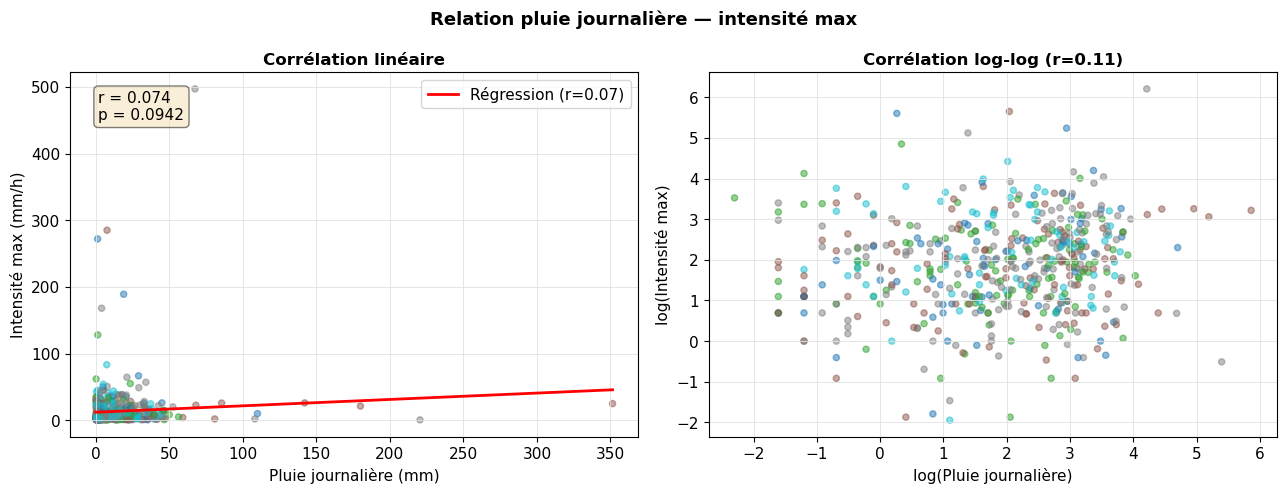

fig2 sauvegardée


In [9]:
# ==============================================================================
# FIGURE 2 — Corrélation pluie journalière vs intensité max
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Gauche : échelle linéaire ---
ax = axes[0]
ax.scatter(df_plot.pluie_mm, df_plot.intensite_max_mm_h,
           alpha=0.5, s=20, c=df_plot.mois, cmap='tab10')
# Ligne de régression
m_lr, b_lr = np.polyfit(df_plot.pluie_mm, df_plot.intensite_max_mm_h, 1)
x_line = np.linspace(df_plot.pluie_mm.min(), df_plot.pluie_mm.max(), 100)
ax.plot(x_line, m_lr*x_line + b_lr, 'r-', linewidth=2, label=f'Régression (r={r_lin:.2f})')
ax.set_xlabel('Pluie journalière (mm)')
ax.set_ylabel('Intensité max (mm/h)')
ax.set_title('Corrélation linéaire', fontsize=12, fontweight='bold')
ax.legend()
ax.text(0.05, 0.95, f'r = {r_lin:.3f}\np = {p_lin:.4f}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# --- Droite : échelle log-log ---
ax2 = axes[1]
ax2.scatter(np.log(df_plot.loc[mask_pos, 'pluie_mm']),
            np.log(df_plot.loc[mask_pos, 'intensite_max_mm_h']),
            alpha=0.5, s=20, c=df_plot.loc[mask_pos, 'mois'], cmap='tab10')
ax2.set_xlabel('log(Pluie journalière)')
ax2.set_ylabel('log(Intensité max)')
ax2.set_title(f'Corrélation log-log (r={r_log:.2f})', fontsize=12, fontweight='bold')

plt.suptitle('Relation pluie journalière — intensité max', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig2 sauvegardée')

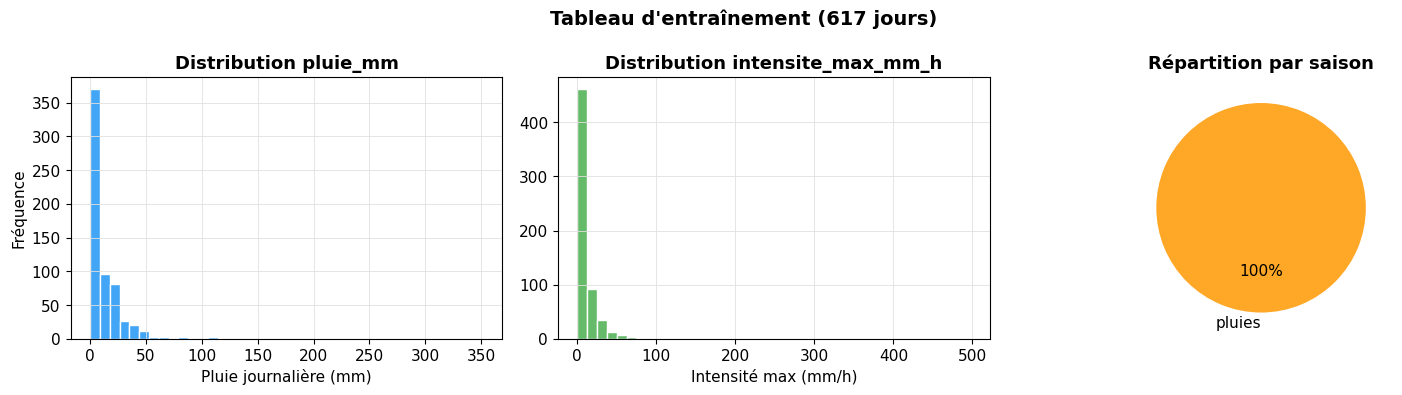

fig3 sauvegardée


In [10]:
# ==============================================================================
# FIGURE 3 — Aperçu du tableau d'entraînement
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution pluie_mm
axes[0].hist(df_train.pluie_mm, bins=40, color='#42A5F5', edgecolor='white')
axes[0].set_xlabel('Pluie journalière (mm)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution pluie_mm', fontweight='bold')

# Distribution intensite_max
axes[1].hist(df_train.intensite_max_mm_h, bins=40, color='#66BB6A', edgecolor='white')
axes[1].set_xlabel('Intensité max (mm/h)')
axes[1].set_title('Distribution intensite_max_mm_h', fontweight='bold')

# Répartition par saison
saison_counts = df_train['saison'].value_counts()
axes[2].pie(saison_counts.values, labels=saison_counts.index,
            autopct='%1.0f%%', colors=['#FFA726', '#42A5F5', '#66BB6A'],
            startangle=90)
axes[2].set_title('Répartition par saison', fontweight='bold')

plt.suptitle(f'Tableau d\'entraînement ({len(df_train)} jours)', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig3_tableau_entrainement.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig3 sauvegardée')

---
## Section 5 — Export du tableau d'entraînement

In [11]:
cols_export = ['date', 'pluie_mm', 'intensite_max_mm_h', 'mois', 'saison']
df_train[cols_export].to_csv('data/tableau_entrainement.csv', index=False)
print(f'data/tableau_entrainement.csv exporté ({len(df_train)} lignes)')
print(f'Colonnes : {cols_export}')
print(f'\nStatistiques :')
df_train[cols_export].describe()

data/tableau_entrainement.csv exporté (617 lignes)
Colonnes : ['date', 'pluie_mm', 'intensite_max_mm_h', 'mois', 'saison']

Statistiques :


,date,pluie_mm,intensite_max_mm_h,mois
count,617,617.000000,617.000000,617.000000
mean,2009-05-23 03:02:02.528363,12.212804,12.484012,8.030794
min,2004-06-03 00:00:00,0.000000,0.142857,6.000000
25%,2006-07-15 00:00:00,0.700000,2.944444,7.000000
50%,2009-07-26 00:00:00,5.500000,6.333333,8.000000
75%,2011-10-23 00:00:00,17.300000,12.650000,9.000000
max,2014-10-31 00:00:00,351.400000,497.000000,10.000000
std,NaN,22.989858,29.216793,1.284533


---
## Résumé

| Indicateur | Valeur |
|------------|--------|
| Source pluviomètre | `data/pluviometre_clean.csv` |
| Source pluviographe | `data/pluviographe_clean.csv` |
| Jointure | Inner join sur `date` |
| Corrélation log-log | r calculé ci-dessus |
| Livrable | `data/tableau_entrainement.csv` |
| Suivant | `n5_modelisation.ipynb` |

---
*Fin du Notebook 4*